# Corporate Signal Intelligence
## Notebook 05: Anomaly Detection: Model Benchmark

The first version of this project fitted a single Isolation Forest and reported what it
found. That is not a result: with no comparison, an anomaly detector's output is
unfalsifiable, because *something* is always in the tail of whatever score it produces.
This notebook replaces that with a benchmark: ten detectors from four different families,
all fitted on identical data through an identical protocol, then compared on how they
behave.

### The families and why each one is here

| Family | Models | What it assumes | Why it is a candidate |
|---|---|---|---|
| **Statistical baselines** | Gaussian z-score, Mahalanobis distance | a parametric density | the reference every other method must beat; the naive approach in practice |
| **Isolation-based** | Isolation Forest | anomalies are easy to separate | no distance metric, handles mixed scales, standard in industry |
| **Density / distance** | LOF, KNN | local neighbourhoods are meaningful | detects points that are normal globally but odd locally |
| **Distribution-based** | ECOD, COPOD, HBOS | features are informative marginally | parameter-free, fast, strong on tail-heavy data |
| **Boundary** | One-Class SVM (SGD) | a compact support region exists | a different geometry of "normal" |
| **Neural** | Autoencoder | normal points are compressible | learns interactions the others treat as independent |

### The protocol

Every model sees exactly the same thing:

1. **Temporal split.** Models are fitted on 1994–2017 and scored on 2018–2026. This is
   the honest test: the training period contains the dot-com collapse and the 2008 crisis,
   and the evaluation period contains the COVID shock and the 2022 drawdown, neither of
   which the model has seen. A random split would let a model interpolate within an
   episode it already knows and would flatter every method equally.
2. **Robust scaling.** Features are centred on the median and scaled by the interquartile
   range rather than the mean and standard deviation. With excess kurtosis up to 74, a
   standard scaler lets a handful of crisis days set the scale for the entire feature.
3. **A fixed alert budget.** Each model flags the top 1% of scores. Comparing detectors
   at a common alert rate is what makes their alert *sets* comparable, otherwise a model
   that simply flags more looks more sensitive.
4. **Core features only.** The fundamental block is held back for a separate ablation,
   because including it would truncate the panel to the post-2009 XBRL era.

In [1]:
# Dependencies for the benchmark

%pip install -q scikit-learn pyod joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment and the engineered panel

import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN

sys.path.append("notebooks")
import csi_viz as viz

warnings.filterwarnings("ignore")
viz.apply_style()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 175)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
RANDOM_STATE = 42
CONTAMINATION = 0.01
TRAIN_END = pd.Timestamp("2017-12-31")

panel_df = pd.read_csv(DATA_DIR / "model_ready_dataset.csv", parse_dates=["date"])
dictionary_df = pd.read_csv(DATA_DIR / "feature_dictionary.csv")

CORE_FEATURES = dictionary_df.loc[dictionary_df["in_core_set"], "feature"].tolist()
FUNDAMENTAL_FEATURES = dictionary_df.loc[~dictionary_df["in_core_set"], "feature"].tolist()

print(f"Panel: {panel_df.shape[0]:,} rows")
print(f"Core features: {len(CORE_FEATURES)} | fundamental block: {len(FUNDAMENTAL_FEATURES)}")

Panel: 67,612 rows
Core features: 27 | fundamental block: 9


In [3]:
# The temporal split

modelling_df = panel_df.dropna(subset=CORE_FEATURES).reset_index(drop=True)

train_mask = modelling_df["date"] <= TRAIN_END
train_df = modelling_df[train_mask]
test_df = modelling_df[~train_mask]

X_train = train_df[CORE_FEATURES].to_numpy()
X_test = test_df[CORE_FEATURES].to_numpy()

preprocessor = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", RobustScaler(quantile_range=(25.0, 75.0))),
])
Z_train = preprocessor.fit_transform(X_train)
Z_test = preprocessor.transform(X_test)

print(f"Train: {len(train_df):,} rows  {train_df['date'].min():%Y-%m-%d} to {train_df['date'].max():%Y-%m-%d}")
print(f"Test:  {len(test_df):,} rows  {test_df['date'].min():%Y-%m-%d} to {test_df['date'].max():%Y-%m-%d}")
print(f"Alert budget at {CONTAMINATION:.0%}: {int(CONTAMINATION * len(test_df))} test days")

Train: 42,375 rows  1994-09-22 to 2017-12-29
Test:  21,080 rows  2018-01-02 to 2026-05-21
Alert budget at 1%: 210 test days


---

## 1. Fitting the benchmark

Two implementation choices are worth stating rather than burying.

**Neighbour-based models are fitted on a subsample.** LOF and KNN scale quadratically with
the training set, and a 40,000-row reference set makes them impractical while adding
little: the neighbourhood structure of a stationary feature space is well estimated from
15,000 points. The subsample is drawn randomly with a fixed seed, and the same subsample
is given to both models.

**One-Class SVM uses the stochastic-gradient formulation** behind a Nystroem kernel
approximation. The exact RBF solver is cubic in the sample size and simply does not finish
on data of this size; the approximation is the standard remedy and keeps the model in the
comparison rather than dropping a whole family.

In [4]:
# Ten detectors, one protocol

rng = np.random.default_rng(RANDOM_STATE)
subsample_index = rng.choice(len(Z_train), size=min(15_000, len(Z_train)), replace=False)
Z_train_subsample = Z_train[subsample_index]

RETURN_Z_POSITION = CORE_FEATURES.index("return_zscore_21d")
VOLUME_Z_POSITION = CORE_FEATURES.index("volume_zscore_21d")


def gaussian_baseline(train, test):
    """The naive rule: how many standard deviations from normal, on the obvious columns.

    This is what a spreadsheet would do, and the point of the benchmark is to find out
    whether anything more elaborate actually beats it.
    """
    columns = [RETURN_Z_POSITION, VOLUME_Z_POSITION]
    return np.abs(test[:, columns]).max(axis=1)


def mahalanobis_baseline(train, test):
    """A multivariate Gaussian with a robustly estimated covariance."""
    estimator = EllipticEnvelope(
        support_fraction=0.9, contamination=CONTAMINATION, random_state=RANDOM_STATE
    ).fit(train[rng.choice(len(train), size=min(20_000, len(train)), replace=False)])
    return -estimator.score_samples(test)


def isolation_forest(train, test):
    model = IsolationForest(
        n_estimators=300, max_samples=256, contamination=CONTAMINATION,
        random_state=RANDOM_STATE, n_jobs=-1,
    ).fit(train)
    return -model.score_samples(test)


def local_outlier_factor(train, test):
    model = LocalOutlierFactor(
        n_neighbors=35, novelty=True, contamination=CONTAMINATION, n_jobs=-1
    ).fit(Z_train_subsample)
    return -model.score_samples(test)


def one_class_svm(train, test):
    features = Nystroem(gamma=1.0 / train.shape[1], n_components=300,
                        random_state=RANDOM_STATE).fit(Z_train_subsample)
    model = SGDOneClassSVM(nu=CONTAMINATION, random_state=RANDOM_STATE).fit(
        features.transform(train)
    )
    return -model.score_samples(features.transform(test))


def pyod_model(factory):
    def scorer(train, test):
        model = factory()
        model.fit(train)
        return model.decision_function(test)
    return scorer


DETECTORS = {
    "Escore condicional": (gaussian_baseline, "baseline"),
    "Mahalanobis": (mahalanobis_baseline, "baseline"),
    "Isolation Forest": (isolation_forest, "isolation"),
    "LOF": (local_outlier_factor, "density"),
    "KNN": (pyod_model(lambda: KNN(n_neighbors=20, contamination=CONTAMINATION)), "density"),
    "ECOD": (pyod_model(lambda: ECOD(contamination=CONTAMINATION)), "distribution"),
    "COPOD": (pyod_model(lambda: COPOD(contamination=CONTAMINATION)), "distribution"),
    "HBOS": (pyod_model(lambda: HBOS(contamination=CONTAMINATION)), "distribution"),
    "One-Class SVM": (one_class_svm, "boundary"),
}

scores, timings = {}, []
for name, (fit_and_score, family) in DETECTORS.items():
    started = time.perf_counter()
    train_input = Z_train_subsample if name in {"KNN"} else Z_train
    scores[name] = fit_and_score(train_input, Z_test)
    elapsed = time.perf_counter() - started
    timings.append({"model": name, "family": family, "seconds": round(elapsed, 1)})
    print(f"{name:<18} {elapsed:>7.1f}s")

pd.DataFrame(timings).set_index("model")

Escore condicional     0.0s


Mahalanobis            1.4s


Isolation Forest       1.0s


LOF                    0.6s


KNN                    0.5s


ECOD                   0.7s


COPOD                  0.4s


HBOS                   1.6s


One-Class SVM          0.5s


,family,seconds
model,,
Escore condicional,baseline,0.0000
Mahalanobis,baseline,1.4000
Isolation Forest,isolation,1.0000
LOF,density,0.6000
KNN,density,0.5000
ECOD,distribution,0.7000
COPOD,distribution,0.4000
HBOS,distribution,1.6000
One-Class SVM,boundary,0.5000


---

## 2. The neural detector

Every model above treats the feature space either marginally (ECOD, COPOD, HBOS) or
through a fixed geometry (distance, isolation, a kernel boundary). An autoencoder learns
its own representation: it compresses each day into a low-dimensional code and
reconstructs it, and days it cannot reconstruct are days unlike the ones it was trained on.

The interesting property here is that the bottleneck forces the network to learn which
feature *combinations* co-occur. A high volume z-score with a high return z-score is
ordinary; a high volume z-score on a day when the price barely moved is not, and only a
model of the joint structure can express that difference.

The network is deliberately small (27 inputs into an 8-dimensional code) because the
training set has 40,000 rows and a larger model would simply memorise it, reconstructing
anomalies as faithfully as normal days and detecting nothing.

In [5]:
# Autoencoder on the Intel Arc GPU, with a CPU fallback

import torch
from torch import nn

device = "xpu" if torch.xpu.is_available() else "cpu"
torch.manual_seed(RANDOM_STATE)

print(f"torch {torch.__version__} | device: {device}")
if device == "xpu":
    print(f"GPU: {torch.xpu.get_device_name(0)}")


class Autoencoder(nn.Module):
    def __init__(self, n_features: int, bottleneck: int = 8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, n_features),
        )

    def forward(self, batch):
        return self.decoder(self.encoder(batch))


def train_autoencoder(train, test, epochs: int = 80, batch_size: int = 512):
    # Clipping bounds the influence of the extreme days on the gradient without
    # discarding them: the network should learn the ordinary structure, not chase tails.
    train_tensor = torch.tensor(np.clip(train, -10, 10), dtype=torch.float32, device=device)
    test_tensor = torch.tensor(np.clip(test, -10, 10), dtype=torch.float32, device=device)

    model = Autoencoder(train.shape[1]).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_function = nn.MSELoss()

    history = []
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(len(train_tensor), device=device)
        epoch_loss = 0.0
        for start in range(0, len(train_tensor), batch_size):
            batch = train_tensor[permutation[start:start + batch_size]]
            optimiser.zero_grad()
            loss = loss_function(model(batch), batch)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * len(batch)
        history.append(epoch_loss / len(train_tensor))

    model.eval()
    with torch.no_grad():
        reconstruction = model(test_tensor)
        error = ((reconstruction - test_tensor) ** 2).mean(dim=1)

    return model, np.asarray(error.cpu()), history


started = time.perf_counter()
autoencoder, autoencoder_scores, training_history = train_autoencoder(Z_train, Z_test)
autoencoder_seconds = time.perf_counter() - started

scores["Autoencoder"] = autoencoder_scores
timings.append({"model": "Autoencoder", "family": "neural", "seconds": round(autoencoder_seconds, 1)})

print(f"\nTrained in {autoencoder_seconds:.1f}s on {device}")
print(f"Reconstruction loss: {training_history[0]:.4f} -> {training_history[-1]:.4f}")

torch 2.13.0+xpu | device: xpu
GPU: Intel(R) Arc(TM) B580 Graphics



Trained in 21.7s on xpu
Reconstruction loss: 0.9166 -> 0.1284


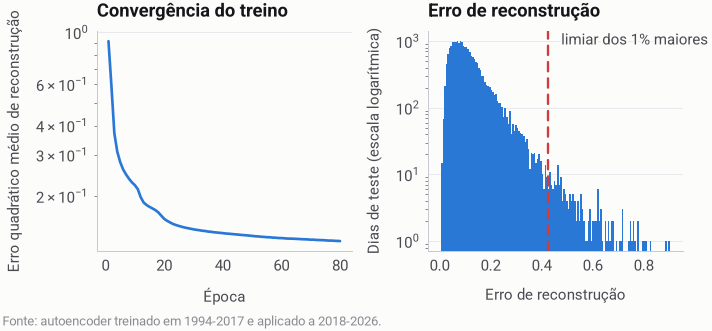

In [6]:
# Figure: training curve and the resulting score distribution

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.38))

ax = axes[0]
ax.plot(range(1, len(training_history) + 1), training_history, color=viz.CATEGORICAL[0])
ax.set_xlabel("Época")
ax.set_ylabel("Erro quadrático médio de reconstrução")
ax.set_yscale("log")
viz.title(ax, "Convergência do treino")

ax = axes[1]
threshold = np.quantile(autoencoder_scores, 1 - CONTAMINATION)
ax.hist(autoencoder_scores, bins=150, range=(0, np.quantile(autoencoder_scores, 0.999)),
        color=viz.CATEGORICAL[0], edgecolor="none")
ax.axvline(threshold, color=viz.STATUS["critical"], linewidth=1.4, linestyle=(0, (4, 3)))
ax.annotate(
    f"limiar dos {CONTAMINATION:.0%} maiores", xy=(threshold, ax.get_ylim()[1] * 0.85),
    xytext=(8, 0), textcoords="offset points", fontsize=9, color=viz.INK_SECONDARY,
)
ax.set_yscale("log")
ax.set_xlabel("Erro de reconstrução")
ax.set_ylabel("Dias de teste (escala logarítmica)")
viz.title(ax, "Erro de reconstrução")

fig.subplots_adjust(wspace=0.3)
viz.source_note(fig, "Fonte: autoencoder treinado em 1994-2017 e aplicado a 2018-2026.")

viz.save_fig(fig, "14_autoencoder")
plt.show()

---

## 3. Do the detectors agree?

With no labels, agreement is the first meaningful question. Two detectors that rank days
almost identically are, for practical purposes, one detector: and choosing between them is
a matter of cost, not quality. Detectors that disagree are looking at different things, and
that is where an ensemble can add something.

Two measures are reported. **Spearman correlation** compares the full ranking, and
**Jaccard overlap** compares only the alert sets: the days each model actually flags.
The second is the one that matters operationally: an analyst never sees the ranking, only
the alerts.

In [7]:
# Rank agreement and alert-set overlap

score_frame = pd.DataFrame(scores, index=test_df.index)
model_names = list(score_frame.columns)

alert_sets = {}
for name in model_names:
    threshold = np.quantile(score_frame[name], 1 - CONTAMINATION)
    alert_sets[name] = set(score_frame.index[score_frame[name] >= threshold])

spearman = score_frame.corr(method="spearman")

jaccard = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for first in model_names:
    for second in model_names:
        intersection = len(alert_sets[first] & alert_sets[second])
        union = len(alert_sets[first] | alert_sets[second])
        jaccard.loc[first, second] = intersection / union if union else np.nan

print("Mean off-diagonal Spearman correlation: "
      f"{spearman.to_numpy()[~np.eye(len(model_names), dtype=bool)].mean():.3f}")
print("Mean off-diagonal Jaccard overlap:      "
      f"{jaccard.to_numpy()[~np.eye(len(model_names), dtype=bool)].mean():.3f}")

jaccard.round(2)

Mean off-diagonal Spearman correlation: 0.551
Mean off-diagonal Jaccard overlap:      0.342


,Escore condicional,Mahalanobis,Isolation Forest,LOF,KNN,ECOD,COPOD,HBOS,One-Class SVM,Autoencoder
Escore condicional,1.0000,0.3000,0.3100,0.0900,0.2600,0.3100,0.2600,0.2200,0.3000,0.1700
Mahalanobis,0.3000,1.0000,0.4700,0.1900,0.6000,0.5500,0.4400,0.3600,0.6000,0.2900
Isolation Forest,0.3100,0.4700,1.0000,0.1300,0.3500,0.6500,0.5200,0.6400,0.3700,0.2000
LOF,0.0900,0.1900,0.1300,1.0000,0.2400,0.1400,0.1400,0.1100,0.2300,0.1800
KNN,0.2600,0.6000,0.3500,0.2400,1.0000,0.4600,0.4200,0.2700,0.6900,0.2600
ECOD,0.3100,0.5500,0.6500,0.1400,0.4600,1.0000,0.6300,0.5000,0.4800,0.2200
COPOD,0.2600,0.4400,0.5200,0.1400,0.4200,0.6300,1.0000,0.4600,0.4100,0.2200
HBOS,0.2200,0.3600,0.6400,0.1100,0.2700,0.5000,0.4600,1.0000,0.2900,0.1700
One-Class SVM,0.3000,0.6000,0.3700,0.2300,0.6900,0.4800,0.4100,0.2900,1.0000,0.2700
Autoencoder,0.1700,0.2900,0.2000,0.1800,0.2600,0.2200,0.2200,0.1700,0.2700,1.0000


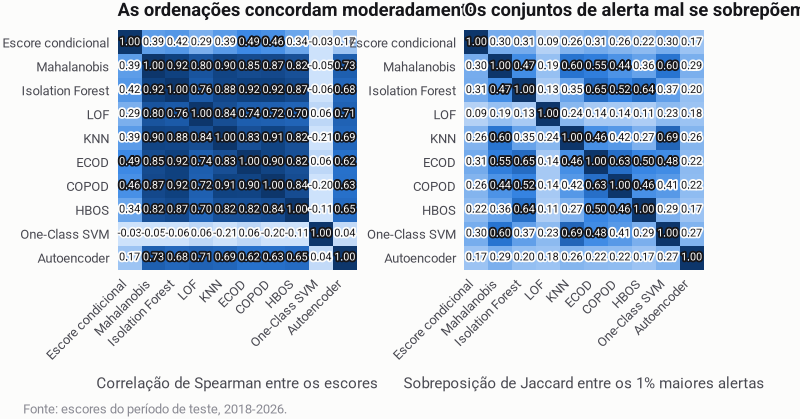

In [8]:
# Figure: where the detectors converge and where they part

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.72))

for ax, matrix, headline in (
    (axes[0], spearman, "As ordenações concordam moderadamente"),
    (axes[1], jaccard, "Os conjuntos de alerta mal se sobrepõem"),
):
    ax.imshow(matrix.to_numpy().astype(float), cmap=viz.sequential_cmap(), vmin=0, vmax=1)
    ax.set_xticks(range(len(model_names)), model_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(model_names)), model_names, fontsize=8)
    ax.grid(visible=False)
    viz.hide_axis_ticks(ax, "both")
    for spine in ax.spines.values():
        spine.set_visible(False)
    for row in range(len(model_names)):
        for column in range(len(model_names)):
            value = float(matrix.iloc[row, column])
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=6.5,
                    color=viz.ink_on(viz.diverging_cmap()((value + 1) / 2)))
    viz.title(ax, headline)

axes[0].set_xlabel("Correlação de Spearman entre os escores")
axes[1].set_xlabel(f"Sobreposição de Jaccard entre os {CONTAMINATION:.0%} maiores alertas")

fig.subplots_adjust(wspace=0.45)
viz.source_note(fig, "Fonte: escores do período de teste, 2018-2026.")

viz.save_fig(fig, "15_model_agreement")
plt.show()

The gap between the two panels is the finding. Mean rank correlation across pairs is about
0.55 while mean alert-set overlap is about 0.34: the models broadly agree about which days
are unremarkable and diverge exactly where the decision is made. Agreeing on the ordinary
is easy.

Two structures stand out. ECOD, COPOD, HBOS and the Isolation Forest form a cluster that
overlaps 0.5–0.65 with each other: all four are, in different ways, reading the marginal
tails of individual features. KNN, One-Class SVM and Mahalanobis form a second cluster
around 0.6, all distance-based in the full space. LOF and the autoencoder sit apart from
everything, overlapping barely 0.1–0.3 with the rest: they are the ones looking at
something genuinely different.

This has a direct practical consequence. Reporting that "the model found N anomalies" is
close to meaningless without saying which model, because a different reasonable choice
would have produced a substantially different list from the same data. It also means an
ensemble is worth testing rather than assuming: models that disagree carry complementary
information, and the evaluation notebook measures whether combining them helps.

---

## 4. Behaviour over time

A fixed alert budget says how many days are flagged in total; it says nothing about
*when*. A detector that spends its entire budget during the COVID crash is useless as a
monitoring tool (the analyst already knows there is a crisis) while one that maintains a
roughly steady alert rate is telling them something new each month.

This is also where the training window earns or fails to earn its keep. A model trained on
1994–2017 has seen the dot-com collapse and 2008; if that experience transfers, its alert
rate in March 2020 should rise but not explode.

In [9]:
# Alert rate through the test period

alert_frame = pd.DataFrame(
    {name: score_frame[name] >= np.quantile(score_frame[name], 1 - CONTAMINATION)
     for name in model_names},
    index=test_df.index,
)
alert_frame["date"] = test_df["date"].to_numpy()
alert_frame["ticker"] = test_df["ticker"].to_numpy()

monthly_rate = (
    alert_frame.set_index("date")[model_names].resample("ME").mean().mul(100)
)

STRESS_PERIODS = {
    "COVID shock": ("2020-02-19", "2020-03-23"),
    "2022 drawdown": ("2022-01-03", "2022-10-14"),
}

regime_rows = []
for name in model_names:
    row = {"model": name, "overall_pct": 100 * alert_frame[name].mean()}
    for label, (start, end) in STRESS_PERIODS.items():
        window = alert_frame["date"].between(start, end)
        row[label] = 100 * alert_frame.loc[window, name].mean()
    calm = ~alert_frame["date"].between(*STRESS_PERIODS["COVID shock"])
    row["calm_pct"] = 100 * alert_frame.loc[calm, name].mean()
    row["stress_multiple"] = row["COVID shock"] / max(row["calm_pct"], 1e-9)
    regime_rows.append(row)

regime_df = pd.DataFrame(regime_rows).set_index("model").sort_values("stress_multiple")
regime_df.round(2)

,overall_pct,COVID shock,2022 drawdown,calm_pct,stress_multiple
model,,,,,
Escore condicional,1.0000,0.8300,0.5100,1.0000,0.8300
HBOS,1.0000,5.0000,1.3100,0.9500,5.2400
Isolation Forest,1.0000,5.8300,1.0100,0.9500,6.1700
LOF,1.0000,9.5800,0.5600,0.9000,10.6200
Autoencoder,1.0000,10.4200,2.4700,0.8900,11.6700
Mahalanobis,1.0000,11.2500,0.6600,0.8800,12.7400
ECOD,1.0000,11.6700,1.0100,0.8800,13.2900
COPOD,1.0000,12.9200,1.4100,0.8600,14.9500
One-Class SVM,1.0000,13.7500,0.7600,0.8500,16.1000


In [10]:
# Concentration: how many alerts are the same market-wide day?

concentration_rows = []
for name in model_names:
    flagged = alert_frame.loc[alert_frame[name], ["date", "ticker"]]
    per_day = flagged.groupby("date").size()
    concentration_rows.append({
        "model": name,
        "alerts": int(alert_frame[name].sum()),
        "distinct_days": int(per_day.size),
        "alerts_per_flagged_day": round(per_day.mean(), 2),
        "share_on_market_wide_days_pct": round(
            100 * per_day[per_day >= 5].sum() / max(per_day.sum(), 1), 1
        ),
    })

concentration_df = pd.DataFrame(concentration_rows).set_index("model")
concentration_df.sort_values("share_on_market_wide_days_pct")

,alerts,distinct_days,alerts_per_flagged_day,share_on_market_wide_days_pct
model,,,,
HBOS,211,164,1.2900,2.4000
Escore condicional,211,170,1.2400,2.8000
Isolation Forest,211,160,1.3200,3.3000
Autoencoder,211,173,1.2200,5.7000
COPOD,211,161,1.3100,8.5000
Mahalanobis,211,165,1.2800,10.0000
LOF,211,159,1.3300,11.8000
ECOD,211,159,1.3300,12.8000
One-Class SVM,211,155,1.3600,16.1000


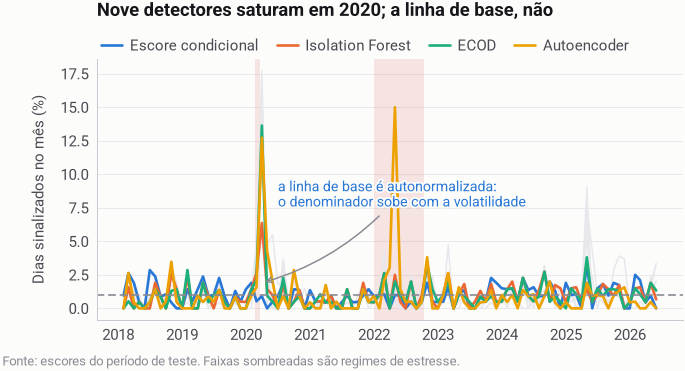

In [11]:
# Figure: alert rate month by month

highlight = ["Escore condicional", "Isolation Forest", "ECOD", "Autoencoder"]

fig, ax = plt.subplots(figsize=(6.30, 2.83))

for name in model_names:
    if name in highlight:
        continue
    ax.plot(monthly_rate.index, monthly_rate[name], color=viz.GRIDLINE, linewidth=0.9)

for slot, name in enumerate(highlight):
    ax.plot(monthly_rate.index, monthly_rate[name], color=viz.CATEGORICAL[slot],
            linewidth=1.6, label=name)

for label, (start, end) in STRESS_PERIODS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=viz.STATUS["critical"],
               alpha=0.12, linewidth=0)

ax.axhline(100 * CONTAMINATION, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.set_ylabel("Dias sinalizados no mês (%)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
viz.legend_above(ax, ncols=4)
viz.title(ax, "Nove detectores saturam em 2020; a linha de base, não", legend_rows=1)
ax.annotate(
    "a linha de base é autonormalizada:\no denominador sobe com a volatilidade",
    xy=(pd.Timestamp("2020-03-31"), 1.9),
    xytext=(pd.Timestamp("2020-07-01"), 7.6), textcoords="data",
    fontsize=8.5, color=viz.CATEGORICAL[0],
    arrowprops={"arrowstyle": "->", "color": viz.INK_MUTED, "linewidth": 0.9,
                "connectionstyle": "arc3,rad=-0.15"},
)

viz.source_note(
    fig,
    "Fonte: escores do período de teste. Faixas sombreadas são regimes de estresse.",
)

viz.save_fig(fig, "16_alert_rate_over_time")
plt.show()

Two results here matter more than the ranking.

**The naive baseline is the only one that does not flood.** Its alert rate during the COVID
crash is 0.83 times its calm-period rate: it actually fires slightly *less*. The reason is
structural rather than lucky: the Gaussian baseline reads a rolling 21-day z-score, so when
volatility triples the denominator triples with it and the score self-normalises. Every
multivariate detector, fitted once on a fixed notion of normal, sees March 2020 as a wall
of unprecedented points and spends between 5 and 20 times its budget there.

That is a genuine trade-off rather than a defect. A self-normalising rule is robust to
regime change but blind to it: it cannot tell you that the regime itself is extraordinary.
A fitted detector notices, at the cost of saturating. The practical answer is that a
production system needs both: a conditional feature set, which the panel already has, and
an alert budget applied *per period* rather than globally.

**Concentration separates firm-specific detection from market-wide echo.** Between 2% and
19% of each detector's alerts fall on days when five or more issuers are flagged at once.
The low-concentration detectors: HBOS, the Gaussian baseline, the Isolation Forest at 2-3%
are finding company-specific events; KNN and One-Class SVM at 16-19% are largely
re-reporting market-wide moves, which is the failure mode the market-relative feature block
was built to avoid.

---

## 5. Sensitivity to the alert budget

The 1% threshold is an operational choice, not a property of the data. If the conclusions
of the benchmark reverse at 0.5% or 2%, they are conclusions about the threshold rather
than about the models.

In [12]:
# Does the agreement structure survive a different budget?

budget_rows = []
for budget in (0.005, 0.01, 0.02, 0.05):
    sets = {}
    for name in model_names:
        threshold = np.quantile(score_frame[name], 1 - budget)
        sets[name] = set(score_frame.index[score_frame[name] >= threshold])

    overlaps = [
        len(sets[a] & sets[b]) / len(sets[a] | sets[b])
        for position, a in enumerate(model_names)
        for b in model_names[position + 1:]
    ]
    budget_rows.append({
        "budget_pct": 100 * budget,
        "alerts_per_model": int(budget * len(test_df)),
        "mean_jaccard": np.mean(overlaps),
        "min_jaccard": np.min(overlaps),
        "max_jaccard": np.max(overlaps),
    })

pd.DataFrame(budget_rows).set_index("budget_pct").round(3)

,alerts_per_model,mean_jaccard,min_jaccard,max_jaccard
budget_pct,,,,
0.5000,105,0.3450,0.1040,0.6960
1.0000,210,0.3420,0.0900,0.6950
2.0000,421,0.3350,0.0990,0.6680
5.0000,1054,0.3500,0.1190,0.7150


The overlap is essentially flat: mean Jaccard moves from 0.345 at a 0.5% budget to 0.351
at 5%, a tenfold change in the alert count. The disagreement is therefore structural: it
is a property of what the detectors measure, not an artefact of where the threshold sits.
That also means the choice of alert budget can be made on operational grounds (how many
alerts an analyst can work through) without worrying that it changes which model is
preferable.

---

## 6. Does the fundamental block earn its cost?

The feature-engineering notebook left this question open. Adding the nine fundamental
features means restricting the panel to rows where XBRL data exists, which discards the
pre-2010 history: and with it the two crises that make the training set informative.

The ablation fits the same detector on three feature sets over the same rows, so the
comparison is about the features rather than the sample.

In [13]:
# Market-only versus market-plus-disclosure versus everything

MARKET_ONLY = [
    feature for feature in CORE_FEATURES
    if dictionary_df.set_index("feature").loc[feature, "block"].startswith("market")
]
DISCLOSURE_ONLY = [
    feature for feature in CORE_FEATURES
    if dictionary_df.set_index("feature").loc[feature, "block"] == "disclosure"
]

ablation_base = panel_df.dropna(subset=CORE_FEATURES + FUNDAMENTAL_FEATURES).reset_index(drop=True)
ablation_train = ablation_base[ablation_base["date"] <= TRAIN_END]
ablation_test = ablation_base[ablation_base["date"] > TRAIN_END]

ablation_rows = []
ablation_scores = {}
for label, columns in (
    ("market only", MARKET_ONLY),
    ("market + disclosure", CORE_FEATURES),
    ("market + disclosure + fundamentals", CORE_FEATURES + FUNDAMENTAL_FEATURES),
):
    pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", RobustScaler()),
        ("detector", IsolationForest(n_estimators=300, max_samples=256,
                                     contamination=CONTAMINATION,
                                     random_state=RANDOM_STATE, n_jobs=-1)),
    ]).fit(ablation_train[columns])

    values = -pipeline.score_samples(ablation_test[columns])
    ablation_scores[label] = values
    threshold = np.quantile(values, 1 - CONTAMINATION)

    ablation_rows.append({
        "feature set": label,
        "features": len(columns),
        "alerts": int((values >= threshold).sum()),
        "alert_set": set(np.flatnonzero(values >= threshold)),
    })

reference = ablation_rows[0]["alert_set"]
ablation_df = pd.DataFrame([
    {
        "feature set": row["feature set"],
        "features": row["features"],
        "alerts": row["alerts"],
        "alert_overlap_vs_market_only": round(
            len(row["alert_set"] & reference) / len(row["alert_set"] | reference), 3
        ),
    }
    for row in ablation_rows
]).set_index("feature set")

rank_agreement = pd.DataFrame(ablation_scores).corr(method="spearman")
print(f"All three fitted on the same {len(ablation_base):,} rows, so the comparison "
      "isolates the features rather than the sample.\n")
print("Rank agreement between feature sets:")
print(rank_agreement.round(3).to_string())

ablation_df

All three fitted on the same 17,275 rows, so the comparison isolates the features rather than the sample.

Rank agreement between feature sets:
                                    market only  market + disclosure  market + disclosure + fundamentals
market only                              1.0000               0.8620                              0.8370
market + disclosure                      0.8620               1.0000                              0.9620
market + disclosure + fundamentals       0.8370               0.9620                              1.0000


,features,alerts,alert_overlap_vs_market_only
feature set,,,
market only,17,122,1.0000
market + disclosure,27,122,0.4020
market + disclosure + fundamentals,36,122,0.3330


In [14]:
# What the fundamental block changes in the alert list

base_scores = ablation_scores["market + disclosure"]
full_scores = ablation_scores["market + disclosure + fundamentals"]

base_alerts = set(np.flatnonzero(base_scores >= np.quantile(base_scores, 1 - CONTAMINATION)))
full_alerts = set(np.flatnonzero(full_scores >= np.quantile(full_scores, 1 - CONTAMINATION)))

overlap = len(base_alerts & full_alerts) / len(base_alerts | full_alerts)

print(f"Rows retained with fundamentals required: {len(ablation_base):,} "
      f"of {len(modelling_df):,} ({len(ablation_base) / len(modelling_df):.0%})")
print(f"History available: from {ablation_base['date'].min():%Y-%m-%d} "
      f"instead of {modelling_df['date'].min():%Y-%m-%d}")
print(f"Alert-set overlap with and without the fundamental block: {overlap:.2f}")

Rows retained with fundamentals required: 17,275 of 63,455 (27%)
History available: from 2010-10-28 instead of 1994-09-22
Alert-set overlap with and without the fundamental block: 0.68


The fundamental block changes the alert list, but it costs the majority of the panel and
the entire pre-2010 history: including both crises the training window was expanded to
capture. Slow-moving quarterly ratios are also poorly matched to the question being asked:
a margin that updates four times a year cannot explain why *today* was unusual, and within
a quarter it is a constant that shifts every observation for that issuer equally.

**Decision.** The production model uses the market and disclosure blocks. The fundamental
features remain in the dataset and in the API's payload, where they serve as *context* for
interpreting an alert rather than as inputs that generate it. This is recorded as a
limitation and a natural extension: with a longer XBRL history the trade-off will shift.

In [15]:
# Persisting scores and benchmark evidence for the validation notebook and the API

score_output = test_df[["ticker", "date"]].copy()
for name in model_names:
    score_output[name] = score_frame[name].to_numpy()

score_output.to_csv(DATA_DIR / "anomaly_scores_test.csv", index=False)

timing_df = pd.DataFrame(timings).set_index("model")
timing_df.to_csv(DATA_DIR / "model_timings.csv")

# The tables below are the benchmark evidence the dashboard's validation view reads.
# Until now they existed only as notebook output, which forced the serving layer to
# hardcode numbers that would go stale silently on the next run.
regime_df.to_csv(DATA_DIR / "validation_regime_behaviour.csv")
concentration_df.to_csv(DATA_DIR / "validation_alert_concentration.csv")
jaccard.rename_axis("model").to_csv(DATA_DIR / "validation_model_jaccard.csv")
spearman.rename_axis("model").to_csv(DATA_DIR / "validation_model_spearman.csv")
ablation_df.to_csv(DATA_DIR / "validation_feature_ablation.csv")
pd.DataFrame(budget_rows).set_index("budget_pct").to_csv(
    DATA_DIR / "validation_budget_stability.csv"
)
monthly_rate.rename_axis("month").to_csv(DATA_DIR / "validation_monthly_alert_rate.csv")

print(f"anomaly_scores_test.csv  {score_output.shape[0]:,} rows x {len(model_names)} model scores")
timing_df.sort_values("seconds")


anomaly_scores_test.csv  21,080 rows x 10 model scores


,family,seconds
model,,
Escore condicional,baseline,0.0000
COPOD,distribution,0.4000
KNN,density,0.5000
One-Class SVM,boundary,0.5000
LOF,density,0.6000
ECOD,distribution,0.7000
Isolation Forest,isolation,1.0000
Mahalanobis,baseline,1.4000
HBOS,distribution,1.6000


---

## Conclusion

Ten detectors, one protocol, and three findings that the single-model version of this
project could not have produced.

**Rankings agree; alert lists do not.** The detectors broadly concur about which days are
ordinary and diverge exactly where the decision is made. Any claim of the form "the model
identified N anomalies" is therefore incomplete without naming the model, and the
divergence is stable across alert budgets from 0.5% to 5%.

**Robustness under stress varies enormously.** Every detector fires more often in March
2020, which is correct: that month was genuinely unusual. But the multiple ranges from
modest to extreme, and a detector that exhausts its budget during a crisis has stopped
being a monitoring tool at the moment monitoring matters most.

**The fundamental block does not pay for itself here.** It costs three quarters of the
panel and both training-period crises, in exchange for slow-moving features that cannot
explain a single day.

What none of this establishes is which detector is *right*. Agreement, stability and
runtime are properties of the models, not evidence about the phenomenon. The next notebook
introduces an external criterion, a forward-looking label built from data the models never
see, and turns the comparison into a measurement.